In [12]:
import numpy as np
import mne
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import os
import pickle

plt.style.use('ggplot')  # pretty matplotlib plots

In [18]:
file_path = '/space/gzanardini/tuh_eeg/preprocessed/full/0/0-raw.pkl'
#list files in directory
with open(file_path, 'rb') as f:
    raw = pickle.load(f)

fs= raw.info['sfreq']
data = raw.get_data()
ch_names = raw.info['ch_names']
print(ch_names)


# retain the first 10second of data
data = data[:, :int(fs*10)]
print(data.shape)


['FP1', 'F3', 'C3', 'P3', 'F7', 'T3', 'T5', 'O1', 'FZ', 'CZ', 'PZ', 'FP2', 'F4', 'C4', 'P4', 'F8', 'T4', 'T6', 'O2', 'PHOTIC PH']
(20, 2500)


/tmp/ipykernel_485150/3853828035.py:7: RuntimeWarning: invalid value encountered in divide
  fft_power_normalized = fft_power / np.sum(fft_power, axis=1, keepdims=True)


(20, 1251)


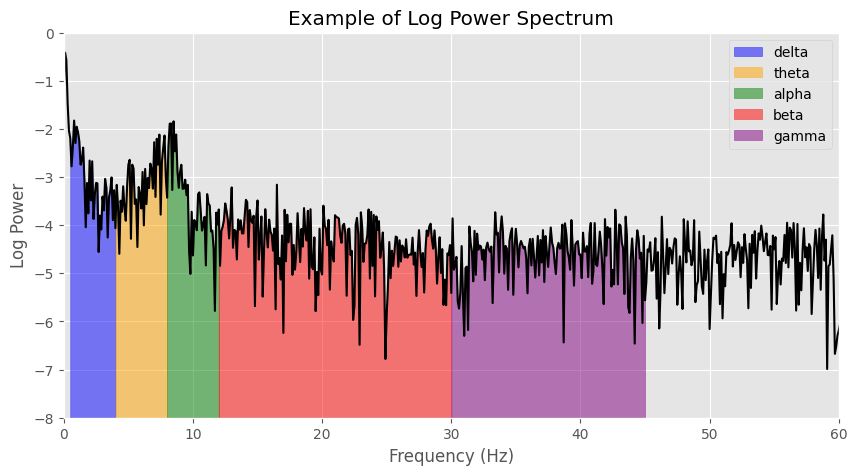

In [46]:
# compute the fft of each channel, plot the spectrum coloring the area under the curve differently for each band
fft = np.fft.rfft(data, axis=1)
fft_freq = np.fft.rfftfreq(data.shape[1], 1/fs)
fft_power = np.abs(fft)**2

# Normalize the power spectrum
fft_power_normalized = fft_power / np.sum(fft_power, axis=1, keepdims=True)

# Convert to log scale
fft_power_log = np.log10(fft_power_normalized + 1e-12)  # Add small epsilon to avoid log(0)

print(fft_power_log.shape)
# plot the spectrum of the first channel
plt.figure(figsize=(10, 5))
plt.plot(fft_freq, fft_power_log[0], color='black')
plt.xlim(0, 60)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Log Power')
plt.title(f'Example of Log Power Spectrum')
plt.ylim(-8,0)
# color the area under the curve differently for each band
bands = {'delta': (0.5, 4), 'theta': (4, 8), 'alpha': (8, 12), 'beta': (12, 30), 'gamma': (30, 45)}
colors = {'delta': 'blue', 'theta': 'orange', 'alpha': 'green', 'beta': 'red', 'gamma': 'purple'}
for band, (fmin, fmax) in bands.items():
    plt.fill_between(fft_freq, plt.ylim()[0], fft_power_log[0], where=(fft_freq >= fmin) & (fft_freq <= fmax), color=colors[band], alpha=0.5, label=band)
plt.legend()
plt.savefig('featplots/log_power_spectrum.pdf') 
plt.show()
# compute the relative power in each band for each channel

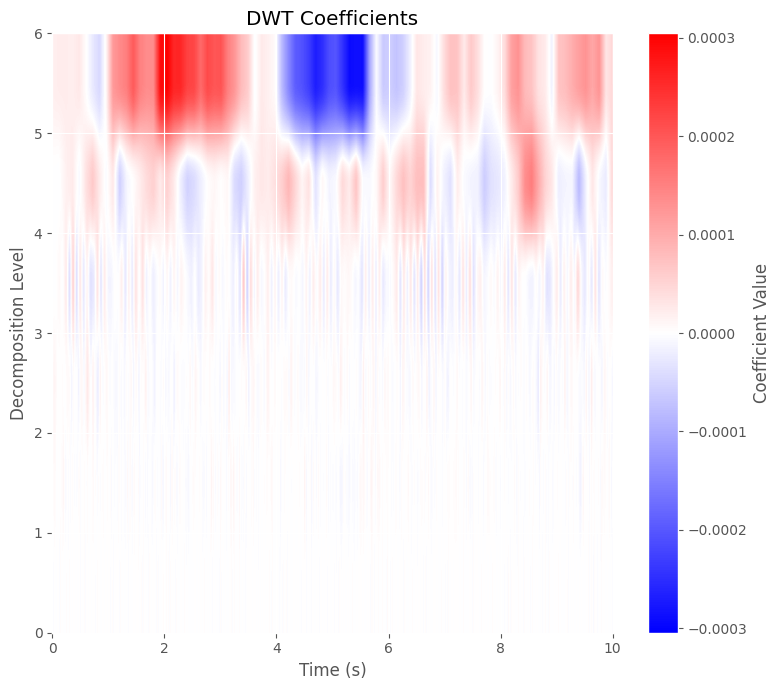

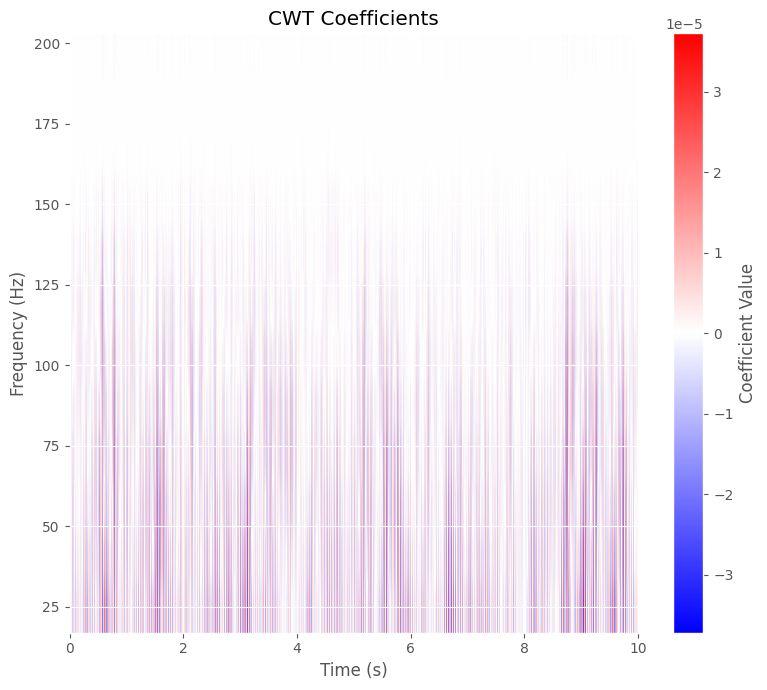

In [58]:
# compute dwt and cwt for the first channel, plot them as images, use morl for cwt, db4 for dwt
# DWT - compute coefficients at each level separately for time-frequency representation
import pywt
coeffs = pywt.wavedec(data[0], 'db4', level=5)

# Create time-frequency representation for DWT
dwt_freqs = []
dwt_times = []
dwt_coeffs_2d = []

for i, coeff in enumerate(coeffs):
    # Calculate corresponding frequency band for each level
    if i == 0:  # approximation coefficients
        freq_band = fs / (2 ** (len(coeffs)))
    else:  # detail coefficients
        freq_band = fs / (2 ** (len(coeffs) - i + 1))
    
    # Create time axis for this level
    time_axis = np.linspace(0, 10, len(coeff))
    
    # Store for plotting
    dwt_freqs.extend([freq_band] * len(coeff))
    dwt_times.extend(time_axis)
    dwt_coeffs_2d.append(coeff)

# Create 2D array for DWT visualization
max_len = max(len(c) for c in dwt_coeffs_2d)
dwt_matrix = np.zeros((len(dwt_coeffs_2d), max_len))
for i, coeff in enumerate(dwt_coeffs_2d):
    # Interpolate to common length for visualization
    if len(coeff) < max_len:
        dwt_matrix[i, :] = np.interp(np.linspace(0, 1, max_len), np.linspace(0, 1, len(coeff)), coeff)
    else:
        dwt_matrix[i, :] = coeff[:max_len]

# CWT   
wavelet = 'morl'
scales = np.arange(1, 13)
coefficients, frequencies = pywt.cwt(data[0], scales, wavelet, sampling_period=1/fs)

# plot DWT as time-frequency map
plt.figure(figsize=(8,7))
plt.imshow(dwt_matrix, extent=[0, 10, 0, len(dwt_coeffs_2d)], 
           cmap='bwr', aspect='auto', vmax=abs(dwt_matrix).max(), vmin=-abs(dwt_matrix).max())   
plt.title('DWT Coefficients')
plt.xlabel('Time (s)')
plt.ylabel('Decomposition Level')
plt.colorbar(label='Coefficient Value')
plt.tight_layout()
plt.savefig('featplots/dwt.pdf')
plt.show()

# plot CWT
plt.figure(figsize=(8,7))
plt.imshow(coefficients, extent=[0, 10, frequencies[-1], frequencies[0]], 
           cmap='bwr', aspect='auto', vmax=abs(coefficients).max(), vmin=-abs(coefficients).max())
plt.title('CWT Coefficients')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.colorbar(label='Coefficient Value')
plt.tight_layout()
plt.savefig('featplots/cwt.pdf')
plt.show()

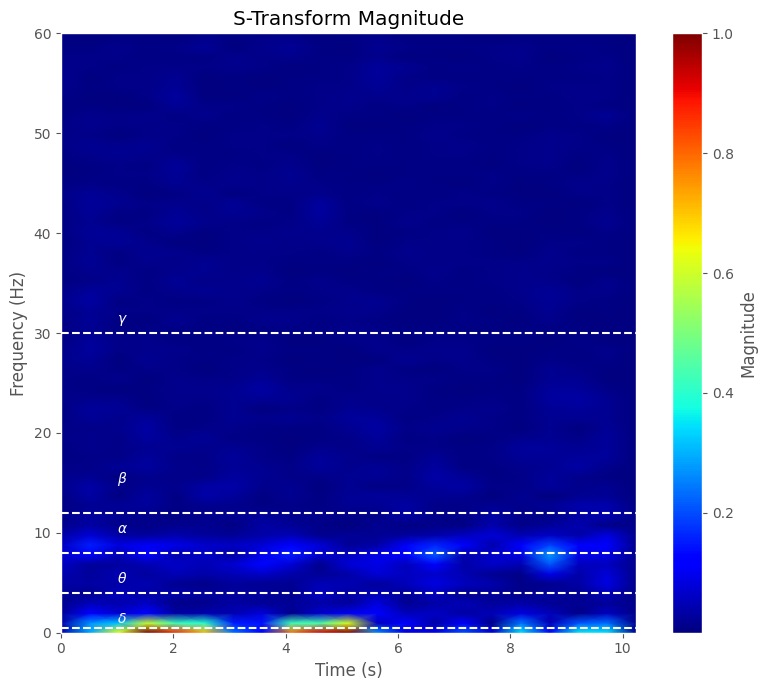

In [ ]:
# do the stft  for the first channel and plot it as an image, plot lines at the band limits, add text labels for each band

from scipy.signal import stft, istft
f, t, Zxx = stft(data[0], fs, nperseg=256)
#normalize Zxx
Zxx = Zxx / np.max(np.abs(Zxx))
plt.figure(figsize=(8,7))
plt.pcolormesh(t, f, np.abs(Zxx), shading='gouraud', cmap='jet')
plt.colorbar(label='Magnitude')     
plt.axhline(0.5, color='white', linestyle='--')
plt.text(1, 1, r'$\delta$', color='white')
plt.axhline(4, color='white', linestyle='--')
plt.text(1, 5, r'$\theta$', color='white')
plt.axhline(8, color='white', linestyle='--')
plt.text(1, 10, r'$\alpha$', color='white')
plt.axhline(12, color='white', linestyle='--')
plt.text(1, 15, r'$\beta$', color='white')
plt.axhline(30, color='white', linestyle='--')
plt.text(1, 31, r'$\gamma$', color='white')

plt.title('S-Transform Magnitude')
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (s)')
plt.ylim(0, 60)
plt.tight_layout()
plt.savefig('featplots/stf.pdf')
plt.show()
#